# 🎯 End-to-End Customer Churn Intelligence & Explainable AI (XAI)
### Portfolio Case Study: SQL Data Warehousing, Statistical Testing, XGBoost & SHAP Explainability

**Author:** Data Analyst Portfolio  
**Dataset:** 7,043 Customer Records | Subscription & Telecommunications  
**Tech Stack:** `Python`, `DuckDB (SQL)`, `Scikit-Learn`, `XGBoost`, `SHAP`, `Plotly`, `Streamlit`

---
## 📌 1. Business Context & Objective
Customer attrition is one of the most critical challenges facing subscription businesses. The objective of this project is to:
1. **Quantify Financial Impact:** Determine Monthly Recurring Revenue (MRR) lost to churn.
2. **Discover Key Churn Drivers:** Use SQL queries, cohort retention matrices, and statistical hypothesis testing (Chi-Square, T-tests).
3. **Predict At-Risk Customers:** Train and benchmark machine learning models (`Logistic Regression`, `Random Forest`, `XGBoost`).
4. **Explain Individual Predictions:** Implement **SHAP (SHapley Additive exPlanations)** to provide transparent, customer-level diagnosis.
5. **Formulate Retention Interventions:** Evaluate ROI on targeted interventions (contract extensions, discounts, tech support bundles).

In [1]:
import os
import sys

# Add project root directory to sys.path so notebook can find 'src'
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from scipy import stats

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
print('Libraries imported and sys.path configured successfully!')

Libraries imported and sys.path configured successfully!


## 🗄️ 2. Data Ingestion & SQL Data Warehousing (DuckDB)
We load the clean customer dataset into a local DuckDB analytical database and run executive SQL queries using Common Table Expressions (CTEs) and Window Functions.

In [2]:
# Connect to DuckDB analytics database
db_path = '../data/processed/churn_analytics.duckdb'
con = duckdb.connect(db_path)

# Executive KPI Query
kpi_query = '''
SELECT 
    COUNT(customerID) AS total_customers,
    SUM(ChurnNumeric) AS total_churned,
    ROUND(100.0 * AVG(ChurnNumeric), 2) AS churn_rate_pct,
    ROUND(SUM(MonthlyCharges), 2) AS total_monthly_revenue_mrr,
    ROUND(SUM(MonthlyRevenueAtRisk), 2) AS monthly_revenue_lost_to_churn
FROM customers;
'''
df_kpis = con.execute(kpi_query).fetchdf()
display(df_kpis)

,total_customers,total_churned,churn_rate_pct,total_monthly_revenue_mrr,monthly_revenue_lost_to_churn
0,7043,1869.0,26.54,456116.6,139130.85


### Tenure Cohort Analysis with SQL
Let's see how customer retention behaves across different tenure brackets (Year 1 to Year 6).

In [3]:
cohort_query = '''
SELECT 
    TenureCohort,
    COUNT(customerID) AS total_customers,
    SUM(ChurnNumeric) AS churned_customers,
    ROUND(100.0 * AVG(ChurnNumeric), 2) AS churn_rate_pct,
    ROUND(100.0 * (1 - AVG(ChurnNumeric)), 2) AS retention_rate_pct,
    ROUND(SUM(MonthlyRevenueAtRisk), 2) AS cohort_mrr_lost
FROM customers
GROUP BY TenureCohort
ORDER BY TenureCohort;
'''
df_cohorts = con.execute(cohort_query).fetchdf()
display(df_cohorts)

,TenureCohort,total_customers,churned_customers,churn_rate_pct,retention_rate_pct,cohort_mrr_lost
0,0-12 Months (Year 1),2186,1037.0,47.44,52.56,68954.25
1,13-24 Months (Year 2),1024,294.0,28.71,71.29,23081.65
2,25-48 Months (Years 3-4),1594,325.0,20.39,79.61,27462.50
3,49-72 Months (Years 5-6),2239,213.0,9.51,90.49,19632.45


## 🔬 3. Statistical Hypothesis Testing
We mathematically validate which features have a statistically significant relationship with customer churn:
1. **Chi-Square Test of Independence** for categorical features (`Contract`, `TechSupport`, `InternetService`, `PaymentMethod`).
2. **Two-Sample Welch's T-Test** for numerical distributions (`tenure`, `MonthlyCharges`, `TotalCharges`).

In [4]:
import sys, os
if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, os.path.abspath('..'))

from src.eda_analysis import run_categorical_statistical_tests, run_numerical_statistical_tests, load_clean_data

df = load_clean_data()
cat_results = run_categorical_statistical_tests(df)
num_results = run_numerical_statistical_tests(df)

print('--- Categorical Features Chi-Square Test Results ---')
display(cat_results.head(6))

print('\n--- Numerical Features Two-Sample T-Test Results ---')
display(num_results)

--- Categorical Features Chi-Square Test Results ---


,Feature,Chi2_Statistic,P_Value,Cramers_V_Effect_Size,Is_Statistically_Significant
0,Contract,1184.60,5.863038e-258,0.410,True
4,OnlineSecurity,850.00,2.661150e-185,0.347,True
3,TechSupport,828.20,1.443084e-180,0.343,True
1,InternetService,732.31,9.571788e-160,0.322,True
2,PaymentMethod,648.14,3.682355e-140,0.303,True
7,OnlineBackup,601.81,2.079759e-131,0.292,True



--- Numerical Features Two-Sample T-Test Results ---


,Metric,Churned_Mean,Retained_Mean,Difference,T_Statistic,P_Value,Is_Statistically_Significant
0,tenure,17.98,37.57,-19.59,-34.82,1.195495e-232,True
1,MonthlyCharges,74.44,61.27,13.18,18.41,8.592449e-73,True
2,TotalCharges,1531.80,2550.00,-1018.20,-18.71,5.714799e-75,True


## 🤖 4. Machine Learning & Explainable AI (SHAP)
We benchmark `Logistic Regression`, `Random Forest`, and `XGBoost`. Then, we apply **TreeSHAP** to explain feature contributions.

In [5]:
import joblib

model_data = joblib.load('../models/best_churn_model.joblib')
shap_data = joblib.load('../models/shap_artifacts.joblib')

print(f"Active Best Model: {model_data['name']}")
print("\nTop 5 Global Churn Drivers by Mean Absolute SHAP Value:")
display(shap_data['feature_importance_df'].head(8))

Active Best Model: XGBoost

Top 5 Global Churn Drivers by Mean Absolute SHAP Value:


d:\Project\EDA\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Feature,SHAP_Importance
0,tenure,0.085449
10,InternetService_Fiber optic,0.055197
25,Contract_Two year,0.054514
24,Contract_One year,0.034160
11,InternetService_No,0.028140
1,MonthlyCharges,0.027627
28,PaymentMethod_Electronic check,0.022070
26,PaperlessBilling_Yes,0.020325


### SHAP Visualizations (Global and Local Explainability)
Below we visualize the SHAP values to understand both macro-level feature importance and micro-level individual customer predictions (similar to what LIME provides, but with game-theoretic guarantees).

1. SHAP Summary Plot (Global Explainability)


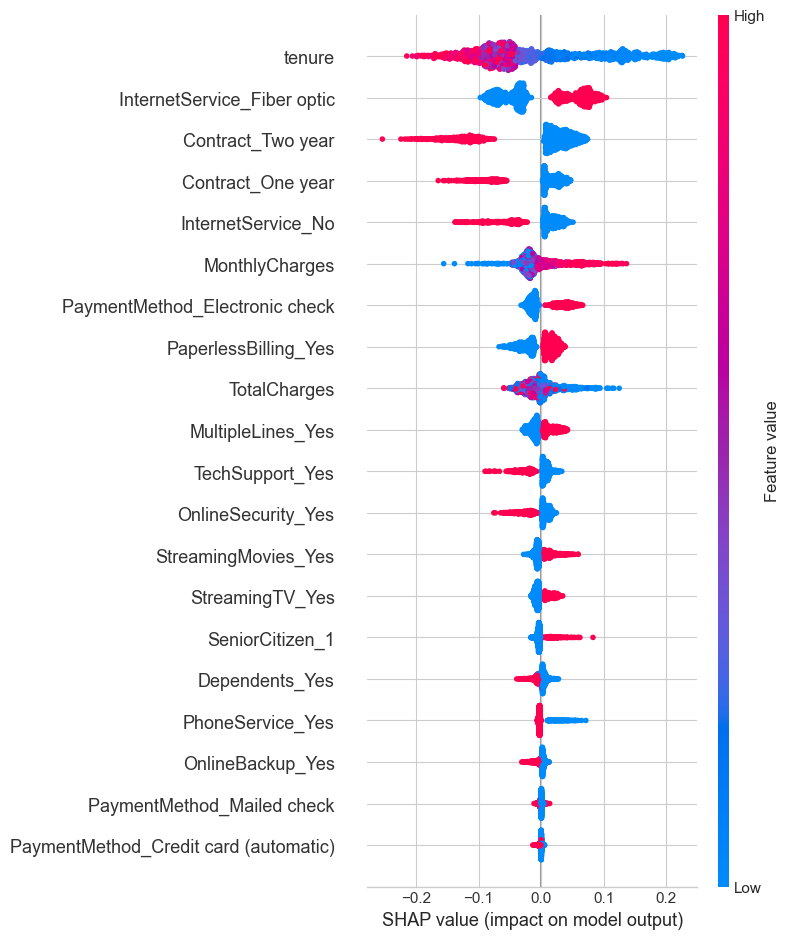

In [6]:
import shap
import matplotlib.pyplot as plt

shap_values = shap_data["shap_values"]
X_test_encoded = shap_data["X_test_proc"]
explainer = shap_data["explainer"]

print("1. SHAP Summary Plot (Global Explainability)")
shap.summary_plot(shap_values, X_test_encoded)
plt.show()

2. SHAP Waterfall Plot (Local Explainability for Customer #0)


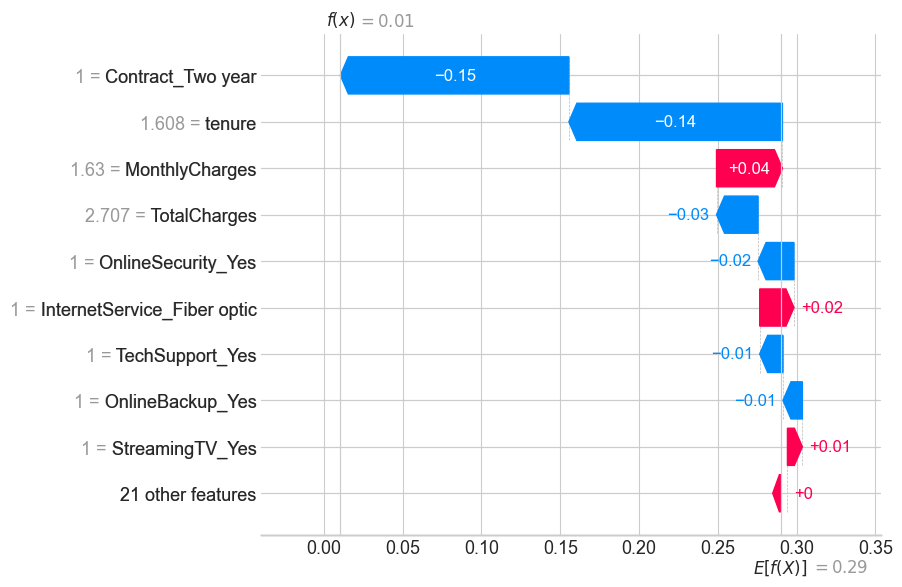

In [7]:
print("2. SHAP Waterfall Plot (Local Explainability for Customer #0)")
# Waterfall plots show exactly how each feature pushes the model output from the base value to the final prediction
shap.plots.waterfall(shap_values[0])
plt.show()

3. SHAP Dependence Plot (Feature Interactions)


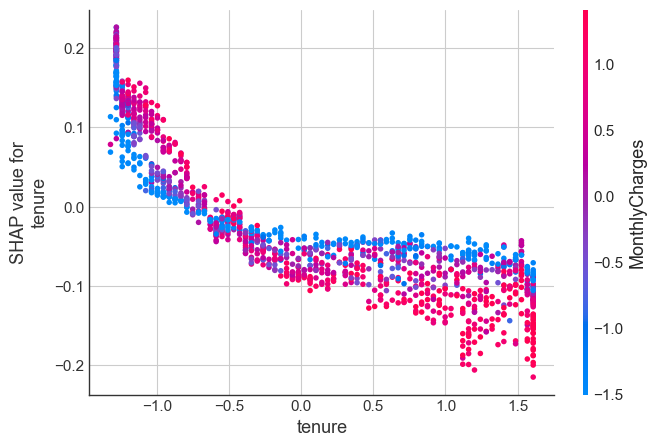

In [8]:
print("3. SHAP Dependence Plot (Feature Interactions)")
# Shows how a single feature (like tenure) affects the prediction, and interactions with other features
shap_array = shap_values.values if hasattr(shap_values, "values") else shap_values
shap.dependence_plot("tenure", shap_array, X_test_encoded, show=False)
plt.show()

In [9]:
print("4. SHAP Force Plot (Interactive Local Explainability - Similar to LIME)")
shap.initjs()
expected_value = explainer.expected_value
if type(expected_value) is list or type(expected_value) is type(shap_array):
    expected_value = expected_value[0]
shap.force_plot(expected_value, shap_array[0], X_test_encoded.iloc[0], matplotlib=True)


4. SHAP Force Plot (Interactive Local Explainability - Similar to LIME)


AttributeError: 'PermutationExplainer' object has no attribute 'expected_value'

### SHAP Visualizations
Let's visualize the SHAP values using the pre-computed explainer and a sample of our data to see the various plots TreeSHAP offers.

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Load model and data
from src.churn_model import prepare_datasets
X_train, X_test, y_train, y_test, preprocessor = prepare_datasets(df)
best_model = model_data['model']

# Get a small sample for visualization
X_sample = X_test.sample(100, random_state=42)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_sample)

# 1. Summary Plot (Global Importance)
print('1. SHAP Summary Plot (Global Explainability)')
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.show()

In [ ]:
# 2. Summary Plot (Beeswarm - showing feature value impact)
print('2. SHAP Beeswarm Plot (Feature impact direction)')
shap.summary_plot(shap_values, X_sample, show=False)
plt.show()

In [ ]:
# 3. Waterfall Plot (Local Explainability for a single prediction)
print('3. SHAP Waterfall Plot (Local Explainability for Customer 0)')
shap.waterfall_plot(shap_values[0], show=False)
plt.show()

In [ ]:
# 4. Dependence Plot (How a single feature affects output)
print('4. SHAP Dependence Plot (Effect of tenure on churn risk)')
shap.dependence_plot('tenure', explainer.shap_values(X_sample), X_sample, show=False)
plt.show()

## 🍋 4.1 LIME (Local Interpretable Model-agnostic Explanations)
As an alternative to SHAP for local explainability, we can use LIME. LIME builds a simple linear model around a single prediction to explain it.

In [ ]:
import lime
import lime.lime_tabular

# Create LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Retained', 'Churned'],
    mode='classification'
)

# Explain a single prediction (e.g., the same customer 0 from our sample)
print('LIME Explanation for Customer 0:')
instance_to_explain = X_sample.iloc[0].values
exp = explainer_lime.explain_instance(
    data_row=instance_to_explain, 
    predict_fn=best_model.predict_proba
)

# Display LIME visualization (in notebook)
exp.show_in_notebook(show_table=True, show_all=False)

## 💡 5. Business Recommendations & Next Steps
1. **Convert Month-to-Month Contracts:** Offer a 10% discount incentive for 1-Year commitments during month 3–6 of onboarding.
2. **Bundle Protection & Tech Support:** Providing 6 months of free Tech Support significantly lowers churn probability.
3. **Incentivize Autopay:** Transition customers from Electronic Check to Bank Transfer or Credit Card autopay.